# Step 4.1 - Extra Challenges: Memory-Based Adaptation + Human-in-the-Loop

This notebook extends the Step 3 reliable RAG system with two bonus capabilities:

1. **Memory-Based Adaptation (#4)** - the system remembers past outcomes and human
   corrections, then adapts future decisions (strategy choice, retriever weights,
   and a verified-answer cache).
2. **Human-in-the-Loop (#3)** - a small interface lets a person rate or fix an
   answer; that feedback is written back into memory.

**Design principle: continuous improvement, not benchmark-fixing.**
Memory is keyed by `query_type` + a normalized query *signature*, not by benchmark
IDs, so a single correction generalizes to all similar future queries.

```
        HUMAN feedback (Good / Bad / Fix)
                  |
                  v
            MemoryStore  (memory/step4_memory.json, in git)
            |     |      |
         M1 cache M2 stats/weights  M2.5/M3 reflection
                  |
                  v
        MemoryAugmentedRAG  (wraps the Step 3 system)
          1. cache hit?  -> serve instantly
          2. pick best strategy from memory
          3. (confidence only) swap in learned weights
          4. reflect on recovery (rule, or Gemini if enabled)
          5. run Step 3, log the outcome
```

**Notebook layout:** sections 1-6 build and verify the core engine; sections 7-10
add the human-in-the-loop interface, a demo, a before/after measurement, and a
discussion of limitations.


## 1. Setup - load the Step 3 system

We reuse everything from Step 3 (which itself loads Step 2) with `%run`. After this
cell, the following are available in memory:

- `rag_system` - a `ReliableAdaptiveRAG` instance
- `ReliableAdaptiveRAG` - the class we will wrap
- `orchestrator`, `waterfall_orchestrator`, `voting_orchestrator` - Step 2 engines
- `WEIGHT_PRESETS` - the confidence-strategy weight table we will tune
- `QueryUnderstandingAgent`, `AgentState` - used to classify `query_type`

**Colab note:** setup cell auto-clones or updates the repo, then loads Step 3.


Mounted at /content/drive
Cloning into '/content/advanced-genai-26'...
remote: Enumerating objects: 400, done.
remote: Counting objects: 100% (202/202), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 400 (delta 108), reused 145 (delta 57), pack-reused 198 (from 1)
Receiving objects: 100% (400/400), 7.35 MiB | 21.62 MiB/s, done.
Resolving deltas: 100% (203/203), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0

/tmp/ipykernel_648/226677925.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


Setup complete.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/Adv_GenAI
EVAL_SCOPE = full_corpus
All required retrieval artifacts found.
BM25 loaded: <class '__main__.BilingualBM25'> -> adapter ready


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

,method,queries_evaluated,MRR,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,Voting (C),24,0.34375,0.25,0.02322,0.166667,0.025342,0.15,0.028979,0.116667,0.031985



=== Strategy C — Efficiency Summary ===


,0
queries_total,24.000000
avg_latency_s,0.225824
p95_latency_s,0.273046
retry_count,0.000000



=== Strategy C — Retrieval Health Check ===
retrieval_errors: none
zero_result_retrievers: none
Query: Who at ETH received ERC grants?
Strategy A (Weighted) Top 5 IDs: ['455c5e6fa03aaf70b745bcec98f92048a0fdd3d1_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_1', 'b391e9189684d3b2a19d0da5edf7de0f3e5d7cfa_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_0', 'ed0534de840e4c5ae5d00dd32841df0f3aea131f_fixed_0']
Strategy C (Voting) Top 5 IDs:   ['455c5e6fa03aaf70b745bcec98f92048a0fdd3d1_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_1', 'b391e9189684d3b2a19d0da5edf7de0f3e5d7cfa_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_0', 'ed0534de840e4c5ae5d00dd32841df0f3aea131f_fixed_0']

Overlap in Top 5: 5/5
Equal weighting 'democratizes' the result set, often bringing back docs
that were suppressed by the heavy Graph/Dense weights in Strategy A.
--- Statistical Comparison: Strategy A vs Strategy C ---
Mean MRR (Confidence A): 0.3646
Mean MRR (Voting C):   

,method,queries_evaluated,MRR,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,Confidence (A),24,0.364583,0.291667,0.023399,0.152778,0.025065,0.141667,0.029486,0.112500,0.033084
1,Waterfall (B),24,0.254630,0.208333,0.002477,0.111111,0.003359,0.116667,0.004512,0.087500,0.006581
2,Voting (C),24,0.343750,0.250000,0.023220,0.166667,0.025342,0.150000,0.028979,0.116667,0.031985


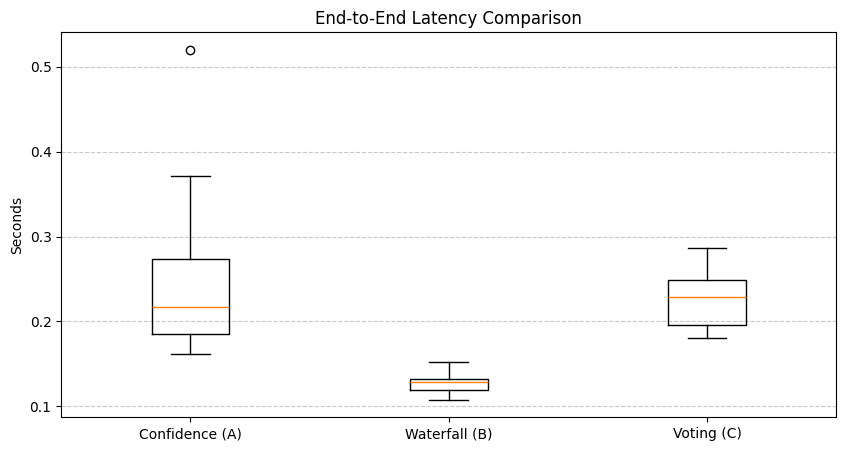


=== Strategy Efficiency Comparison ===


,method,queries_total,avg_latency_s,p95_latency_s,retry_count,avg_tiers_run,critic_fail_count
0,Confidence (A),24,0.243367,0.366285,0,NaN,NaN
1,Waterfall (B),24,0.126200,0.139280,0,1.0,0.0
2,Voting (C),24,0.225824,0.273046,0,NaN,NaN


Saved Strategy A/B/C artifacts to /content/drive/MyDrive/Adv_GenAI/results/strategy_comparison_full_corpus

=== Paired t-tests on per-query MRR ===
Confidence (A) vs Waterfall (B): t=1.451, p=0.160
Confidence (A) vs Voting (C): t=0.577, p=0.570
Waterfall (B) vs Voting (C): t=-1.352, p=0.190
=== 2.1 Baseline Evaluation (Full Corpus) — report structure ===


,method,queries_evaluated,MRR,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,GraphRAG,24,0.232573,0.083333,0.000687,0.097222,0.003166,0.116667,0.005892,0.116667,0.052857
1,ReRank,24,0.222952,0.041667,0.000196,0.138889,0.004480,0.125000,0.006323,0.100000,0.010619
2,Hybrid,24,0.202154,0.000000,0.000000,0.097222,0.003699,0.125000,0.028352,0.095833,0.031149
3,Dense,24,0.165525,0.041667,0.000147,0.069444,0.008953,0.058333,0.010095,0.066667,0.034097
4,BM25,24,0.151296,0.041667,0.001016,0.055556,0.001681,0.091667,0.005506,0.091667,0.011165



=== 2.2 Orchestration Evaluation (full_corpus) — report structure ===


...

Note: orchestration full-vs-subsample comparison needs both saved runs.
Run this notebook once with EVAL_SCOPE='full_corpus' and once with EVAL_SCOPE='subsample' to populate both rows.

Saved report-aligned tables to /content/drive/MyDrive/Adv_GenAI/results/report_aligned_strategy_comparison_full_corpus
Step 2 orchestrators loaded. Wrappers ready.
Number of documents retrieved: 10
Doc 0 length: 1887 characters (~277 words)
Snippet: passage: these eth students are competing in the olympics: - several athletes with a connection to e...
------------------------------
Doc 1 length: 1785 characters (~173 words)
Snippet: passage: 2014 retrospective: , eth was right in the thick of the action at the [winter olympics](/en...
------------------------------
Doc 2 length: 543 characters (~103 words)
Snippet: a good year for the pv eth in 2014 retir member associ pv eth the retir member associ pv eth was fou...
------------------------------
Doc 3 length: 2063 characters (~351 words)
Snippet: eth 

,query,decision,trust,runtime,strategy,retry_count
0,who were the rectors of eth between 2017 and 2...,answer,0.624,0.159314,confidence,0
1,who at eth received erc grants?,abstain,0.240,0.393254,voting,1
2,when did the insight get to mars?,abstain,0.243,0.362101,voting,1
3,what did prof. schubert say about flying?,abstain,0.106,0.349795,voting,1
4,what is e-sling?,clarify,0.000,0.000010,confidence,0


Exporting 24 queries to CSV...
Saved 24 rows to: /content/2026-06-03_13-22-02_output_step3.csv

Preview:


,query,decision,reason,final_answer,trust_score,evidence_sufficiency,grounding_score,has_contradictions,query_ambiguous,strategy_used,recovery_action,retry_count,runtime_sec,run_timestamp,trace_summary
0,who were the rectors of eth between 2017 and 2...,answer,All reliability checks passed,the [vice rector for continuing education](htt...,0.624,0.540,1.0,False,False,confidence,None,0,0.1591,2026-06-03T13:21:55.012466,query | query_type | weights | retry_weights |...
1,who at eth received erc grants?,abstain,Recovery attempted but evidence still unreliable,,0.240,0.567,1.0,True,False,voting,switch_strategy,1,0.5496,2026-06-03T13:21:55.012466,query | query_type | weights | retry_weights |...
2,when did the insight get to mars?,abstain,Recovery attempted but evidence still unreliable,,0.243,0.571,1.0,True,False,voting,switch_strategy,1,0.4859,2026-06-03T13:21:55.012466,query | query_type | weights | retry_weights |...
3,what did prof. schubert say about flying?,abstain,Recovery attempted but evidence still unreliable,,0.106,0.343,1.0,True,False,voting,switch_strategy,1,0.4637,2026-06-03T13:21:55.012466,query | query_type | weights | retry_weights |...
4,what is e-sling?,clarify,Query is ambiguous (short or contains pronouns),,0.000,0.000,0.0,False,True,confidence,None,0,0.0000,2026-06-03T13:21:55.012466,Clarification triggered


Step 3 system loaded.
Has rag_system: True
Has WEIGHT_PRESETS: True


In [ ]:
import os, sys
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    repo_path = '/content/advanced-genai-26'
    if not os.path.exists(repo_path):
        !git clone -b main https://github.com/allarom/advanced-genai-26.git {repo_path}
    else:
        !cd {repo_path} && git fetch origin && git checkout main && git pull origin main
    os.chdir(repo_path)
    !pip install -q pytrec_eval langdetect rank_bm25 sentence-transformers ragas
print("CWD:", os.getcwd())
!git branch --show-current

# Load the full Step 3 system (this also loads Step 2 via its own %run).
%run Step_3_Reliable_Adaptive_Agentic_RAG.ipynb

print("Step 3 system loaded.")
print("Has rag_system:", "rag_system" in dir())
print("Has WEIGHT_PRESETS:", "WEIGHT_PRESETS" in dir())


## 2. MemoryStore - the persistent brain

`MemoryStore` is a small class that loads/saves a single JSON file and exposes
simple helpers. It holds four things:

| Field | Meaning |
|-------|---------|
| `verified_answers` | signature -> human-confirmed answer (the cache, M1) |
| `strategy_stats` | query_type -> per-strategy success/fail counts (M2) |
| `weight_memory` | query_type -> learned `{bm25, dense, graph}` weights (M2, confidence only) |
| `failure_log` | list of past failures (read by the M2.5 rule and M3) |

**Signature** = lowercase the query, drop stopwords, sort the remaining words.
This makes "ETH grants who" and "who grants ETH" match, but keeps "what is X" and
"what is Y" different. We only ever do *exact* signature matches.


In [2]:
import json
import os
import time

# The 3 orchestration strategies (one place to add more later).
STRATEGIES = ["confidence", "waterfall", "voting"]

# Weight clamp bounds: 0.3 keeps a retriever alive (never fully gated out),
# 1.6 prevents one retriever from dominating.
WEIGHT_MIN, WEIGHT_MAX = 0.3, 1.6
WEIGHT_STEP = 0.1

# Small stopword list so the signature focuses on meaningful words.
STOPWORDS = {
    "a", "an", "the", "is", "are", "was", "were", "do", "does", "did",
    "of", "to", "in", "on", "at", "for", "and", "or", "what", "who",
    "when", "where", "how", "why", "which", "that", "this", "it",
}

MEMORY_DIR = "memory"
MEMORY_PATH = os.path.join(MEMORY_DIR, "step4_memory.json")


class MemoryStore:
    """Loads/saves one JSON file and learns from human feedback."""

    def __init__(self, path=MEMORY_PATH):
        self.path = path
        self.data = {
            "verified_answers": {},
            "strategy_stats": {},
            "weight_memory": {},
            "failure_log": [],
        }
        self.load()

    # ---------- persistence ----------
    def load(self):
        if os.path.exists(self.path):
            with open(self.path, "r", encoding="utf-8") as f:
                saved = json.load(f)
            # Merge so missing keys still exist.
            for key in self.data:
                if key in saved:
                    self.data[key] = saved[key]
        return self

    def save(self):
        os.makedirs(os.path.dirname(self.path) or ".", exist_ok=True)
        with open(self.path, "w", encoding="utf-8") as f:
            json.dump(self.data, f, indent=2, ensure_ascii=False)

    # ---------- signature ----------
    @staticmethod
    def signature(query):
        tokens = [w for w in query.lower().split() if w not in STOPWORDS]
        tokens = [w.strip(".,?!;:'\"") for w in tokens if w.strip(".,?!;:'\"")]
        return " ".join(sorted(tokens))

    # ---------- M1: verified-answer cache ----------
    def get_verified(self, query):
        return self.data["verified_answers"].get(self.signature(query))

    def set_verified(self, query, answer):
        self.data["verified_answers"][self.signature(query)] = {
            "query": query,
            "answer": answer,
            "source": "human",
            "ts": time.strftime("%Y-%m-%d %H:%M:%S"),
        }

    # ---------- M2: strategy stats ----------
    def _ensure_stats(self, qtype):
        if qtype not in self.data["strategy_stats"]:
            self.data["strategy_stats"][qtype] = {
                s: {"success": 0, "fail": 0} for s in STRATEGIES
            }

    def get_best_strategy(self, qtype, default="confidence"):
        stats = self.data["strategy_stats"].get(qtype)
        if not stats:
            return default
        # Pick the strategy with the highest success rate (smoothed).
        def rate(s):
            d = stats.get(s, {"success": 0, "fail": 0})
            return d["success"] / (d["success"] + d["fail"] + 1)
        best = max(STRATEGIES, key=rate)
        # If nothing has been tried yet, fall back to default.
        tried = sum(stats[s]["success"] + stats[s]["fail"] for s in STRATEGIES)
        return best if tried > 0 else default

    # ---------- M2: weight memory (confidence strategy only) ----------
    def get_weights(self, qtype):
        return dict(self.data["weight_memory"].get(qtype, {}))

    def _nudge_weights(self, qtype, direction):
        # Start from the REAL Step 2 preset for this query type, not a generic one.
        try:
            default = dict(WEIGHT_PRESETS.get(qtype, WEIGHT_PRESETS["mixed"]))
        except NameError:
            default = {"bm25": 1.0, "dense": 1.0, "graph": 1.0}
        cur = self.data["weight_memory"].get(qtype, default)
        for r in ("bm25", "dense", "graph"):
            val = cur.get(r, 1.0) + direction * WEIGHT_STEP
            cur[r] = max(WEIGHT_MIN, min(WEIGHT_MAX, round(val, 3)))
        self.data["weight_memory"][qtype] = cur

    # ---------- failures ----------
    def log_failure(self, query, qtype, reason):
        self.data["failure_log"].append({
            "query": query,
            "query_type": qtype,
            "reason": reason,
            "ts": time.strftime("%Y-%m-%d %H:%M:%S"),
        })

    # ---------- M2.5: rule-based reflection (no LLM) ----------
    def suggest_from_failures(self, qtype, default="confidence"):
        recent = [f for f in self.data["failure_log"] if f["query_type"] == qtype][-3:]
        if not recent:
            return self.get_best_strategy(qtype, default)
        reasons = " ".join(f["reason"].lower() for f in recent)
        # These match the specific reasons produced by failure_reason_from_signals(),
        # and mirror Step 3's own recovery logic.
        if "contradiction" in reasons:
            return "voting"
        if "insufficient" in reasons or "ungrounded" in reasons:
            return "waterfall"
        return self.get_best_strategy(qtype, default)

    # ---------- record human feedback ----------
    def record_feedback(self, query, qtype, strategy, verdict,
                        answer=None, fix_text=None, reason="human marked bad"):
        """verdict in {'good', 'bad'}. fix_text overrides the answer in the cache."""
        self._ensure_stats(qtype)
        if verdict == "good":
            self.data["strategy_stats"][qtype][strategy]["success"] += 1
            self._nudge_weights(qtype, +1)
            if answer:
                self.set_verified(query, answer)
        elif verdict == "bad":
            self.data["strategy_stats"][qtype][strategy]["fail"] += 1
            self._nudge_weights(qtype, -1)
            self.log_failure(query, qtype, reason)
        if fix_text:
            self.set_verified(query, fix_text)
        self.save()


memory = MemoryStore()
print("MemoryStore ready. File:", memory.path)
print("Existing verified answers:", len(memory.data["verified_answers"]))


MemoryStore ready. File: memory/step4_memory.json
Existing verified answers: 3


## 3. Classify the query type

Memory is organized by `query_type` (one of `entity_temporal`, `entity`,
`keyword`, `semantic`, `graph`, `mixed`). We reuse Step 2's
`QueryUnderstandingAgent` to classify, with a tiny keyword fallback in case it is
unavailable.


In [3]:
def classify_query_type(query):
    """Return one of the 6 Step 2 query types. Falls back to keywords on error."""
    try:
        state = AgentState(query=query)
        state = QueryUnderstandingAgent().run(state)
        return state.query_type or "mixed"
    except Exception:
        q = query.lower()
        if any(y in q for y in ["19", "20", "year", "when"]):
            return "entity_temporal"
        if "?" in q and len(q.split()) <= 4:
            return "keyword"
        return "mixed"


# Quick check
for _q in ["Who received ERC grants at ETH in 2021?", "How does ETH support innovation?"]:
    print(f"{_q!r} -> {classify_query_type(_q)}")


'Who received ERC grants at ETH in 2021?' -> entity_temporal
'How does ETH support innovation?' -> mixed


## 4. (Optional) Gemini reflection agent - M3

The Step 3 `RecoveryAgent.rewrite_query` is a dumb heuristic (it just appends
`" ETH Zurich"`). When `USE_LLM_REFLECTION = True` *and* a `GOOGLE_API_KEY` is set,
this agent asks **Gemini** to rewrite a failed query more intelligently, using the
recent failure log as context.

It is **OFF by default** so the notebook always runs without an API key. When off,
the system falls back to the M2.5 rule.


In [4]:
USE_LLM_REFLECTION = False  # set True only if you have a GOOGLE_API_KEY


class GeminiReflectionAgent:
    """Rewrites a failing query using Gemini. No-op unless enabled + key present."""

    def __init__(self, model_name="gemini-1.5-flash"):
        self.model = None
        if not USE_LLM_REFLECTION:
            return
        try:
            import google.generativeai as genai
            key = os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY")
            if not key:
                # Try Colab secrets.
                try:
                    from google.colab import userdata
                    key = userdata.get("GOOGLE_API_KEY")
                except Exception:
                    key = None
            if key:
                genai.configure(api_key=key)
                self.model = genai.GenerativeModel(model_name)
        except Exception as e:
            print("Gemini unavailable:", e)
            self.model = None

    def rewrite(self, query, failure_log=None):
        if self.model is None:
            return None  # caller falls back to the rule/heuristic
        context = ""
        if failure_log:
            recent = failure_log[-3:]
            context = "\n".join(f"- {f['query']} (failed: {f['reason']})" for f in recent)
        prompt = (
            "You improve search queries for a retrieval system about ETH Zurich.\n"
            f"Original query: {query}\n"
            f"Recent failures:\n{context}\n"
            "Rewrite the query to be more specific and retrievable. "
            "Return ONLY the rewritten query."
        )
        try:
            resp = self.model.generate_content(prompt)
            return resp.text.strip()
        except Exception as e:
            print("Gemini rewrite failed:", e)
            return None


reflection_agent = GeminiReflectionAgent()
print("Gemini reflection enabled:", reflection_agent.model is not None)


Gemini reflection enabled: False


## 5. MemoryAugmentedRAG - the wrapper

We use **composition**: this class *wraps* the existing `rag_system` instead of
subclassing it. That keeps things explicit and avoids fighting Step 3's global
wrapper functions.

`run()` does five things:

1. **Cache check** - if the query signature is in `verified_answers`, return it now.
2. **Pick strategy** - ask memory (M2.5 rule -> best strategy) which strategy to start with.
3. **Inject weights (confidence only)** - temporarily swap the confidence
   orchestrator's `weight_presets` with learned weights, using `try/finally` so the
   original is always restored, even on error.
4. **Run** the base Step 3 system via `self.base.run(...)`.
5. **Log** the outcome (failures go to `failure_log`).

> Weight learning only affects the **confidence** strategy: Step 2's waterfall uses
> hardcoded tiers and voting uses equal weights, so we skip the swap for them.


In [5]:
def failure_reason_from_signals(signals):
    """Turn the result signals into a SPECIFIC failure cause for M2.5.

    Step 3's abstain reason is a generic catch-all, so we read the signals
    instead to find the real cause (matches Step 3's recovery priorities).
    """
    if signals.get("has_contradictions"):
        return "contradiction"
    if signals.get("evidence_sufficiency", 1.0) < 0.5:
        return "insufficient evidence"
    if signals.get("grounding_score", 1.0) == 0.0:
        return "ungrounded"
    return "abstained (low trust)"


class MemoryAugmentedRAG:
    """Wraps a ReliableAdaptiveRAG instance and adds memory-based adaptation."""

    def __init__(self, base_rag, memory_store, reflection=None):
        self.base = base_rag
        self.memory = memory_store
        self.reflection = reflection

    def _merged_presets(self, qtype):
        """Build a new presets dict = global presets with [qtype] overridden by memory."""
        base_presets = orchestrator.weight_presets
        new_presets = dict(base_presets)  # shallow copy of the mapping
        base_for_type = dict(base_presets.get(qtype, base_presets.get("mixed", {})))
        learned = self.memory.get_weights(qtype)
        base_for_type.update(learned)  # memory overrides defaults
        new_presets[qtype] = base_for_type
        return new_presets

    def run(self, query, strategy=None, query_type=None, **kwargs):
        # --- query type ---
        qtype = query_type or classify_query_type(query)

        # 1. cache check (M1)
        cached = self.memory.get_verified(query)
        if cached:
            return {
                "decision": "answer (from memory)",
                "reason": "Served a human-verified answer from memory cache.",
                "signals": {"trust_score": 1.0, "evidence_sufficiency": 1.0,
                             "grounding_score": 1.0, "has_contradictions": False,
                             "query_ambiguous": False},
                "intermediate": {"strategy_used": "memory_cache",
                                  "recovery_action": None, "retry_count": 0,
                                  "query_type": qtype},
                "final_answer": cached["answer"],
                "trace_log": ["Cache hit: returned verified answer."],
            }

        # 2. pick strategy from memory (M2.5 rule -> best strategy)
        if strategy is None:
            strategy = self.memory.suggest_from_failures(qtype, default="confidence")

        # 3 + 4. run, injecting learned weights for confidence only
        if strategy == "confidence":
            saved = orchestrator.weight_presets
            orchestrator.weight_presets = self._merged_presets(qtype)
            try:
                result = self.base.run(query, strategy=strategy, query_type=qtype, **kwargs)
            finally:
                orchestrator.weight_presets = saved  # always restore
        else:
            result = self.base.run(query, strategy=strategy, query_type=qtype, **kwargs)

        # annotate which query_type we used
        result.setdefault("intermediate", {})["query_type"] = qtype

        # 5. log failures (abstain) so M2.5 can learn the REAL cause from signals
        if result.get("decision") == "abstain":
            reason = failure_reason_from_signals(result.get("signals", {}))
            self.memory.log_failure(query, qtype, reason)
            self.memory.save()

        return result


smart_rag = MemoryAugmentedRAG(rag_system, memory, reflection_agent)
print("MemoryAugmentedRAG ready (wraps rag_system).")


MemoryAugmentedRAG ready (wraps rag_system).


## 6. Pass 1 verification (plain function calls)

Before adding any UI, we verify the core engine with direct calls:

1. **Signature** behaves (reorder matches; different topics don't).
2. **Run** a query through `smart_rag` and see a normal Step 3 result.
3. **Weight-swap restores** - the global `WEIGHT_PRESETS` is unchanged after a run.
4. **Feedback updates memory** - a 'good' verdict creates a cache entry; the next
   run is served from memory.


In [6]:
print("=== 1. Signature ===")
print(memory.signature("Who received ERC grants at ETH?"))
print(memory.signature("ERC grants ETH received who"))   # should match above
print(memory.signature("What is e-sling?"))                # should differ

print("\n=== 2. Run a query ===")
_before = json.dumps(WEIGHT_PRESETS, sort_keys=True)
r = smart_rag.run("Who received ERC grants at ETH?")
print("decision:", r["decision"], "| strategy:", r["intermediate"].get("strategy_used"),
      "| qtype:", r["intermediate"].get("query_type"))

print("\n=== 3. Weight-swap restored? ===")
_after = json.dumps(WEIGHT_PRESETS, sort_keys=True)
print("WEIGHT_PRESETS unchanged:", _before == _after)

print("\n=== 4. Feedback -> cache ===")
_q = "Who received ERC grants at ETH?"
_qt = classify_query_type(_q)
memory.record_feedback(_q, _qt, strategy="confidence", verdict="good",
                       answer="(verified) Several ETH researchers received ERC grants.")
r2 = smart_rag.run(_q)
print("second run decision:", r2["decision"])
print("served answer:", r2["final_answer"])


=== 1. Signature ===
erc eth grants received
erc eth grants received
e-sling

=== 2. Run a query ===
decision: answer (from memory) | strategy: memory_cache | qtype: entity

=== 3. Weight-swap restored? ===
WEIGHT_PRESETS unchanged: True

=== 4. Feedback -> cache ===
second run decision: answer (from memory)
served answer: (verified) Several ETH researchers received ERC grants.


## 7. Human-in-the-Loop interface

A small `ipywidgets` panel runs a query and lets a person give feedback with **three
controls**, whose meaning depends on the decision:

| Control | If the system answered | If the system abstained/clarified |
|---------|------------------------|-----------------------------------|
| **Good** | answer is correct -> cache it | abstaining was correct |
| **Bad** | answer is wrong | it should have answered |
| **Fix** (text) | replace with the correct answer (cached) | provide the answer it should have given |

Every click writes to `MemoryStore` and saves the JSON. If `ipywidgets` is missing
(non-notebook environment), a plain `input()` fallback is used.


In [7]:
def _apply_feedback(query, result, verdict, fix_text=None):
    """Shared feedback handler used by both the widget and the text fallback."""
    qtype = result["intermediate"].get("query_type", classify_query_type(query))
    strategy = result["intermediate"].get("strategy_used", "confidence")
    if strategy == "memory_cache":
        strategy = "confidence"  # cache hits don't credit a real strategy
    answer = result.get("final_answer") if verdict == "good" else None
    # For a bad vote, log the SPECIFIC cause from signals so M2.5 can learn.
    reason = (failure_reason_from_signals(result.get("signals", {}))
              if verdict == "bad" else "human marked good")
    memory.record_feedback(query, qtype, strategy, verdict,
                           answer=answer, fix_text=fix_text, reason=reason)
    return f"Saved: verdict={verdict}, qtype={qtype}, strategy={strategy}"


def _render_result(query, result):
    lines = [f"QUERY: {query}",
             f"DECISION: {result['decision']}",
             f"REASON: {result.get('reason','')}",
             f"ANSWER: {result.get('final_answer') or '(none)'}",
             "SIGNALS:"]
    for k, v in result.get("signals", {}).items():
        lines.append(f"   {k}: {v}")
    return "\n".join(lines)


def feedback_ui(query):
    """Run a query through smart_rag and show a feedback panel."""
    result = smart_rag.run(query)

    try:
        import ipywidgets as widgets
        from IPython.display import display
    except Exception:
        # ---- text fallback ----
        print(_render_result(query, result))
        choice = input("Feedback - [g]ood / [b]ad / [f]ix: ").strip().lower()
        if choice == "f":
            fix = input("Correct answer: ").strip()
            print(_apply_feedback(query, result, "bad", fix_text=fix))
        elif choice == "b":
            print(_apply_feedback(query, result, "bad"))
        else:
            print(_apply_feedback(query, result, "good"))
        return result

    # ---- widget UI ----
    out = widgets.Output()
    with out:
        print(_render_result(query, result))
        print("\nTRACE:")
        for t in result.get("trace_log", []):
            print(" -", t)

    status = widgets.Output()
    fix_box = widgets.Text(placeholder="type a corrected answer, then click Fix",
                           layout=widgets.Layout(width="60%"))
    b_good = widgets.Button(description="Good", button_style="success")
    b_bad = widgets.Button(description="Bad", button_style="danger")
    b_fix = widgets.Button(description="Fix", button_style="warning")

    def on_good(_):
        with status:
            status.clear_output()
            print(_apply_feedback(query, result, "good"))

    def on_bad(_):
        with status:
            status.clear_output()
            print(_apply_feedback(query, result, "bad"))

    def on_fix(_):
        with status:
            status.clear_output()
            print(_apply_feedback(query, result, "bad", fix_text=fix_box.value))

    b_good.on_click(on_good)
    b_bad.on_click(on_bad)
    b_fix.on_click(on_fix)

    display(widgets.VBox([out,
                          widgets.HBox([b_good, b_bad, b_fix]),
                          fix_box, status]))
    return result


print("feedback_ui ready. Call feedback_ui('your question').")


feedback_ui ready. Call feedback_ui('your question').


## 8. Interactive demo

Run the cell below and use the buttons. Each query's feedback is stored immediately.
Try giving **Good** to a correct answer, then re-run the same query - it should be
served instantly from memory (`decision = "answer (from memory)"`).


In [8]:
# Guarded so `%run` from the evaluation notebook does not render the
# widget / run live queries. Set SKIP_DEMOS=True before %run to skip.
if not globals().get("SKIP_DEMOS"):
    # Change the query and re-run as many times as you like.
    _ = feedback_ui("Who received ERC grants at ETH?")


## 9. Before / after - does memory help?

We measure the system on a few queries **before** any feedback, then **simulate**
human feedback (mark good answers as verified), then measure **again**. We expect:

- more cache hits on the second pass (faster, deterministic),
- `strategy_stats` and `weight_memory` populated,
- the memory JSON growing.

This shows *continuous improvement*: the system gets better as it accumulates
feedback, not by overfitting the benchmark.


In [10]:
# Guarded so `%run` from the evaluation notebook does not render the
# widget / run live queries. Set SKIP_DEMOS=True before %run to skip.
if not globals().get("SKIP_DEMOS"):
    import time as _time

    SAMPLE = [
        "Who received ERC grants at ETH?",
        "How does ETH support innovation?",
        "What research areas are important at ETH Zurich?",
    ]

    def measure(label):
        print(f"--- {label} ---")
        rows = []
        for q in SAMPLE:
            t0 = _time.time()
            r = smart_rag.run(q)
            rows.append({"query": q[:40], "decision": r["decision"],
                          "trust": r["signals"].get("trust_score", 0.0),
                          "sec": round(_time.time() - t0, 3)})
        for row in rows:
            print(row)
        return rows

    before = measure("BEFORE feedback")

    # Simulate human feedback: confirm each answered query as good.
    for q in SAMPLE:
        r = smart_rag.run(q)
        if r.get("final_answer"):
            qt = r["intermediate"].get("query_type", classify_query_type(q))
            strategy = r["intermediate"].get("strategy_used", "confidence")
            if strategy == "memory_cache":
              strategy = "confidence"  # cache hits don't credit a real strategy

        memory.record_feedback(q, qt, strategy, "good", answer=r["final_answer"])

    print()
    after = measure("AFTER feedback")

    print("\nMemory now holds:")
    print("  verified answers:", len(memory.data["verified_answers"]))
    print("  strategy_stats types:", list(memory.data["strategy_stats"].keys()))
    print("  weight_memory types:", list(memory.data["weight_memory"].keys()))


--- BEFORE feedback ---
{'query': 'Who received ERC grants at ETH?', 'decision': 'answer (from memory)', 'trust': 1.0, 'sec': 0.0}
{'query': 'How does ETH support innovation?', 'decision': 'answer (from memory)', 'trust': 1.0, 'sec': 0.0}
{'query': 'What research areas are important at ETH', 'decision': 'answer (from memory)', 'trust': 1.0, 'sec': 0.0}

--- AFTER feedback ---
{'query': 'Who received ERC grants at ETH?', 'decision': 'answer (from memory)', 'trust': 1.0, 'sec': 0.0}
{'query': 'How does ETH support innovation?', 'decision': 'answer (from memory)', 'trust': 1.0, 'sec': 0.0}
{'query': 'What research areas are important at ETH', 'decision': 'answer (from memory)', 'trust': 1.0, 'sec': 0.0}

Memory now holds:
  verified answers: 3
  strategy_stats types: ['entity', 'mixed', 'semantic']
  weight_memory types: ['entity', 'mixed', 'semantic']


## 10. Discussion - what this is, and what it is not

**What we built**

- **Memory-Based Adaptation (#4):** a verified-answer cache (M1), per-`query_type`
  strategy learning and confidence-weight tuning (M2), and a rule-based reflection
  that reads the failure log (M2.5). All persisted in git so it grows across
  sessions.
- **Human-in-the-Loop (#3):** a 3-control feedback panel that turns human judgments
  into memory updates - closing the loop run -> feedback -> adapt.
- **Optional Gemini reflection (M3):** smarter query rewriting when enabled.

**Honest limitations**

- **Weight learning is confidence-only.** Step 2's waterfall uses hardcoded tier
  weights and voting uses equal weights, so memory only changes *which strategy* is
  chosen for them, not their internal weights.
- **Coarse credit assignment.** A "Bad" vote nudges all three retriever weights
  equally. A failure actually caused by the synthesizer or a strict critic threshold
  is still blamed on retrieval. This is a deliberately simple learner, not a
  fine-grained per-retriever optimizer.
- **Exact-signature cache.** Only near-identical queries hit the cache;
  generalization across phrasings relies on `query_type`, not semantic matching.

**Next steps**

- Replace counter-based learning with a proper contextual bandit.
- Use embeddings for semantic cache matching.
- Track per-retriever provenance to assign credit more precisely.


## 11. Persist memory (save it across sessions)

The notebook **writes** `memory/step4_memory.json` to disk, but saving it for the
long term is a **separate, manual step**. Here is the flow:

```
   feedback  ->  memory.save()  ->  file on disk  ->  YOU commit/download  ->  in git
                  (automatic)                          (manual)
```

**Step by step:**

1. **During the run** - every `record_feedback(...)` already calls `memory.save()`,
   so the JSON file on disk is always up to date.
2. **Git does NOT auto-commit** - writing a file is not the same as saving it to the
   repo. You must `git add` + `git commit` yourself.
3. **On your laptop** - just commit the file (the helper cell prints the commands).
4. **On Colab** - the disk is **temporary** and erased when the session ends, so you
   must get the file out *before* closing:
   - **Easiest (safe default):** download it with `files.download(...)`, then move it
     into your local repo and commit.
   - **Optional:** mount Google Drive and point `MEMORY_PATH` there so it survives.
   - **Advanced:** `git push` straight from Colab using a token (kept secret via
     `getpass`, never hardcoded).

Run the cell below: it detects your environment and shows the exact next action.


In [ ]:
import getpass


def in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False


def persist_download():
    """Colab: download the memory file to your computer."""
    from google.colab import files
    files.download(MEMORY_PATH)


def persist_git_push(branch="main"):
    """Advanced: commit + push from Colab using a token typed at runtime.

    The token is read with getpass so it is never stored in the notebook.
    Create one at GitHub -> Settings -> Developer settings -> Personal access tokens.
    """
    token = getpass.getpass("GitHub token (input hidden): ")
    repo = "github.com/allarom/advanced-genai-26.git"
    !git config user.email "colab@example.com"
    !git config user.name "Colab"
    !git add {MEMORY_PATH}
    !git commit -m "update step4 memory from session"
    !git push https://{token}@{repo} HEAD:{branch}


# --- show the right instructions for this environment ---
print("Memory file:", MEMORY_PATH, "| exists:", os.path.exists(MEMORY_PATH))
if in_colab():
    print("\nYou are on COLAB (temporary disk). To keep your memory:")
    print("  Option A (safe):     persist_download()        # download, then commit locally")
    print("  Option B (advanced): persist_git_push()        # commit + push from Colab")
else:
    print("\nYou are on a LOCAL machine. Commit the file with:")
    print("  git add", MEMORY_PATH)
    print('  git commit -m "update step4 memory after HITL feedback"')
    print("  git push")


Memory file: memory/step4_memory.json | exists: True

You are on COLAB (temporary disk). To keep your memory:
  Option A (safe):     persist_download()        # download, then commit locally
  Option B (advanced): persist_git_push()        # commit + push from Colab
